# 01 — Exploratory Data Analysis (EDA)

**Student Academic Risk — Early Intervention System**

This notebook explores the `Student_Academic_Risk_Dataset_120_Year1_Semester1.xlsx` dataset to understand:
- Data structure and quality
- Distribution of academic indicators
- Relationships between features and academic risk
- Key patterns that inform model development

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load the Dataset

In [2]:
import os

def find_project_root():
    curr = os.path.abspath(os.getcwd())
    for _ in range(4):
        if os.path.exists(os.path.join(curr, 'Student_Academic_Risk_Dataset_120_Year1_Semester1.xlsx')):
            return curr
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
    return os.path.abspath(os.path.join('..', '..'))

PROJECT_ROOT = find_project_root()
DATASET_PATH = os.path.join(PROJECT_ROOT, 'Student_Academic_Risk_Dataset_120_Year1_Semester1.xlsx')
df = pd.read_excel(DATASET_PATH)
print(f'Dataset loaded from: {DATASET_PATH}')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Unique students: {df["Student_ID"].nunique()}')
print(f'Unique courses: {df["Course_Name"].nunique()}')
df.head()


Dataset loaded from: c:\Users\Favour Kampangire\Documents\Student-Academic-Attrition-Early-Intervention-System\Student_Academic_Risk_Dataset_120_Year1_Semester1.xlsx
Dataset shape: 600 rows × 20 columns
Unique students: 120
Unique courses: 5


,Enrollment_ID,Student_ID,Gender,Programme,Academic_Year,Semester,Course_ID,Course_Name,Attempt_Number,Enrollment_Type,CA_Score,Assignment_Average,Test_Average,Attendance_Percentage,Number_of_Courses,Previous_Semester_GPA,Previous_Failed_Courses,Final_Exam_Score,Final_Result,Academic_Risk
0,ENR000001,BSDS001,Male,Bachelor of Science in Data Science,1,1,BICT1101,End User Computing,1,NEW,66.67,61.19,60.82,74.91,5,NaN,0,69.12,PASS,LOW
1,ENR000002,BSDS001,Male,Bachelor of Science in Data Science,1,1,BICT1102,Introduction to Programming,1,NEW,45.44,48.07,43.71,62.89,5,NaN,0,65.66,PASS,MEDIUM
2,ENR000003,BSDS001,Male,Bachelor of Science in Data Science,1,1,BICT1103,Computer and Communication Technology,1,NEW,61.09,62.09,52.34,70.10,5,NaN,0,65.85,PASS,LOW
3,ENR000004,BSDS001,Male,Bachelor of Science in Data Science,1,1,COMM1101,Communication Skills I,1,NEW,52.05,63.68,48.38,87.21,5,NaN,0,75.23,PASS,LOW
4,ENR000005,BSDS001,Male,Bachelor of Science in Data Science,1,1,MATH1101,Precalculus,1,NEW,55.18,58.30,53.02,66.60,5,NaN,0,57.76,PASS,MEDIUM


## 2. Dataset Overview

In [3]:
# Column information
print('=== Column Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values (except Previous_Semester_GPA which is expected for Year 1).')
print(f'\nPrevious_Semester_GPA missing: {df["Previous_Semester_GPA"].isnull().sum()} out of {len(df)} (all Year 1 Sem 1 students)')

=== Column Types ===
Enrollment_ID                  str
Student_ID                     str
Gender                         str
Programme                      str
Academic_Year                int64
Semester                     int64
Course_ID                      str
Course_Name                    str
Attempt_Number               int64
Enrollment_Type                str
CA_Score                   float64
Assignment_Average         float64
Test_Average               float64
Attendance_Percentage      float64
Number_of_Courses            int64
Previous_Semester_GPA      float64
Previous_Failed_Courses      int64
Final_Exam_Score           float64
Final_Result                   str
Academic_Risk                  str
dtype: object

=== Missing Values ===
Previous_Semester_GPA    600
dtype: int64

Previous_Semester_GPA missing: 600 out of 600 (all Year 1 Sem 1 students)


In [4]:
# Basic statistics for numeric columns
df.describe().round(2)

,Academic_Year,Semester,Attempt_Number,CA_Score,Assignment_Average,Test_Average,Attendance_Percentage,Number_of_Courses,Previous_Semester_GPA,Previous_Failed_Courses,Final_Exam_Score
count,600.0,600.0,600.0,600.00,600.00,600.00,600.00,600.0,0.0,600.0,600.00
mean,1.0,1.0,1.0,66.56,68.59,64.96,78.75,5.0,NaN,0.0,82.44
std,0.0,0.0,0.0,10.43,10.43,11.96,9.28,0.0,NaN,0.0,11.68
min,1.0,1.0,1.0,37.85,37.14,21.97,51.52,5.0,NaN,0.0,43.66
25%,1.0,1.0,1.0,59.63,61.64,57.08,72.34,5.0,NaN,0.0,73.77
50%,1.0,1.0,1.0,66.83,68.13,65.17,79.01,5.0,NaN,0.0,82.83
75%,1.0,1.0,1.0,73.51,75.77,73.37,85.20,5.0,NaN,0.0,91.14
max,1.0,1.0,1.0,96.91,95.00,95.00,100.00,5.0,NaN,0.0,100.00


## 3. Target Variable Distribution

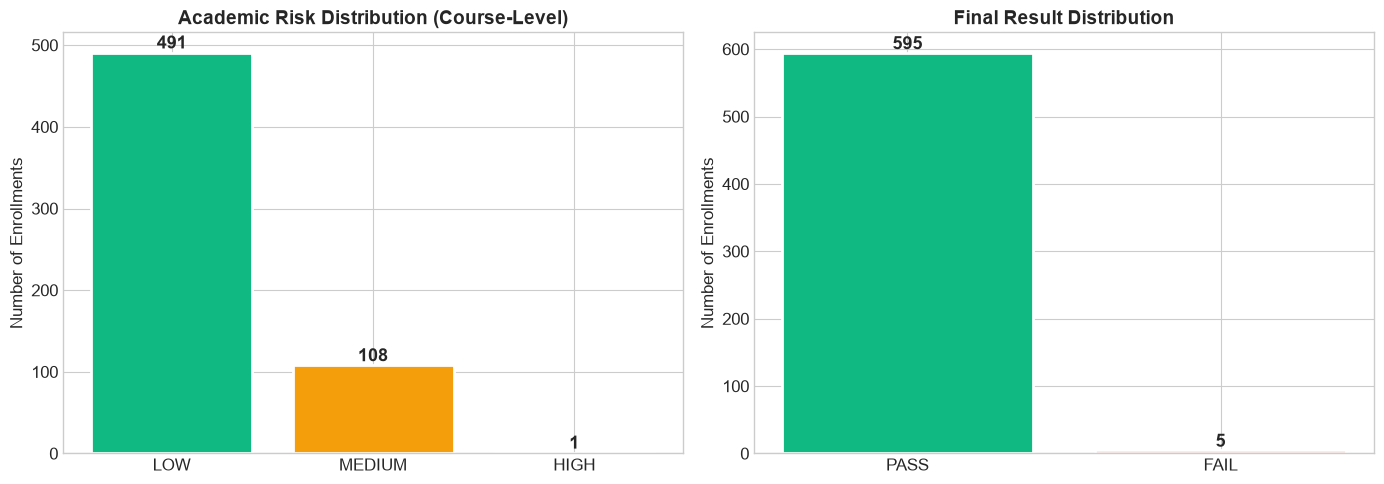


Cross-tabulation: Academic Risk vs Final Result
Final_Result   FAIL  PASS  All
Academic_Risk                 
HIGH              1     0    1
LOW               0   491  491
MEDIUM            4   104  108
All               5   595  600


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Academic Risk distribution
risk_colors = {'LOW': '#10B981', 'MEDIUM': '#F59E0B', 'HIGH': '#EF4444'}
risk_counts = df['Academic_Risk'].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, 
            color=[risk_colors[r] for r in risk_counts.index],
            edgecolor='white', linewidth=2)
axes[0].set_title('Academic Risk Distribution (Course-Level)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Enrollments')
for i, (idx, val) in enumerate(zip(risk_counts.index, risk_counts.values)):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold', fontsize=13)

# Final Result distribution
result_counts = df['Final_Result'].value_counts()
result_colors = {'PASS': '#10B981', 'FAIL': '#EF4444'}
axes[1].bar(result_counts.index, result_counts.values,
            color=[result_colors[r] for r in result_counts.index],
            edgecolor='white', linewidth=2)
axes[1].set_title('Final Result Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Enrollments')
for i, (idx, val) in enumerate(zip(result_counts.index, result_counts.values)):
    axes[1].text(i, val + 5, str(val), ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('../data_science/data/01_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCross-tabulation: Academic Risk vs Final Result')
print(pd.crosstab(df['Academic_Risk'], df['Final_Result'], margins=True))

## 4. Distribution of Key Academic Indicators

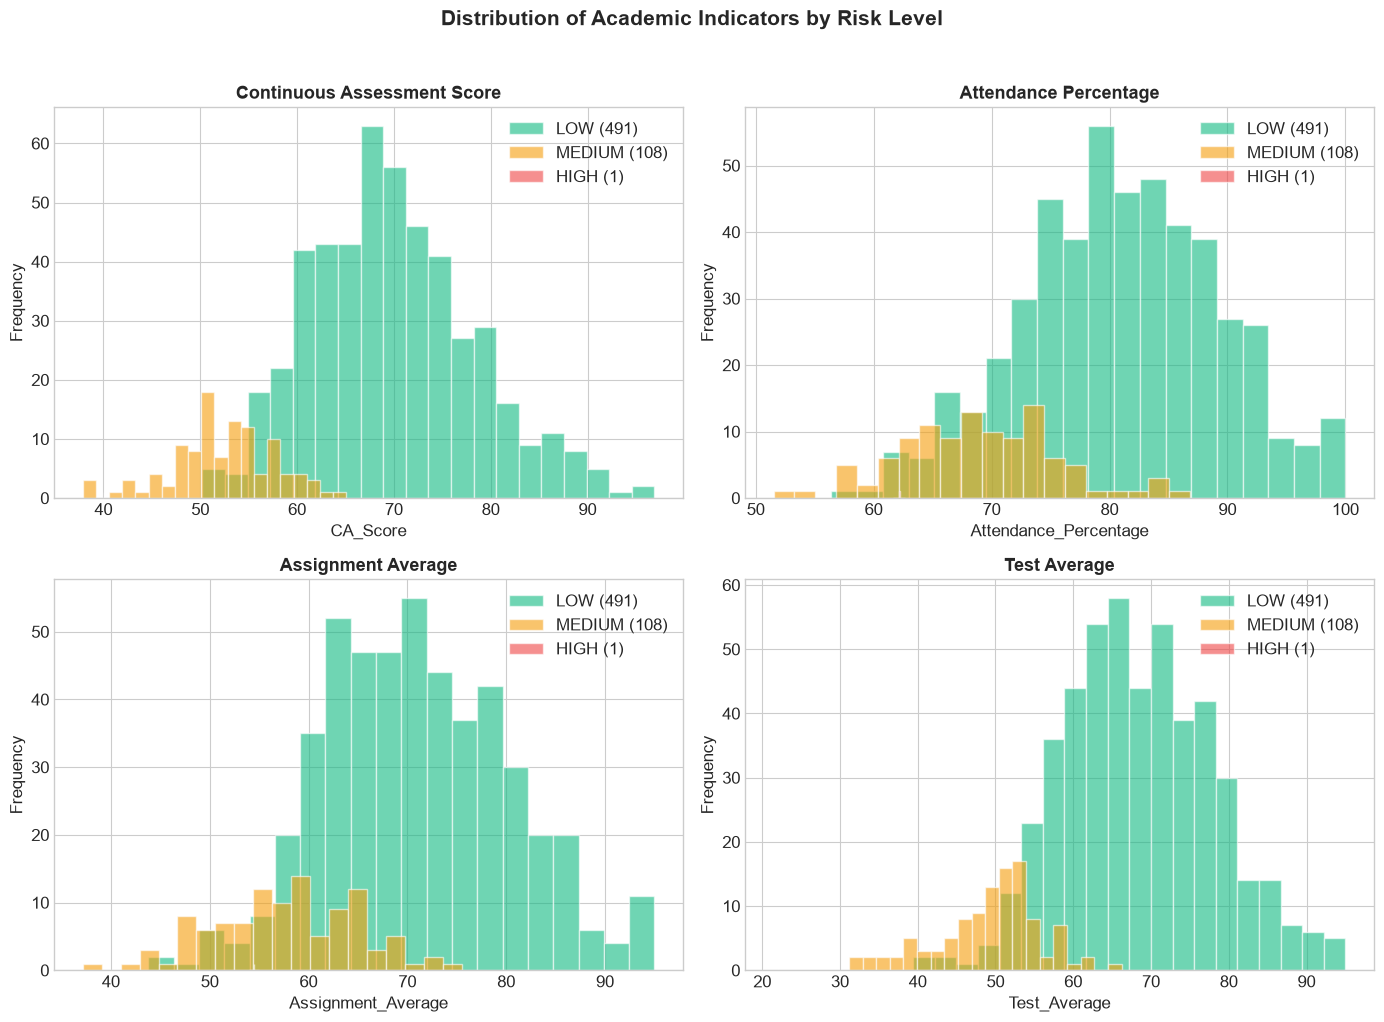

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

indicators = [
    ('CA_Score', 'Continuous Assessment Score'),
    ('Attendance_Percentage', 'Attendance Percentage'),
    ('Assignment_Average', 'Assignment Average'),
    ('Test_Average', 'Test Average')
]

for ax, (col, title) in zip(axes.flatten(), indicators):
    for risk in ['LOW', 'MEDIUM', 'HIGH']:
        subset = df[df['Academic_Risk'] == risk][col]
        if len(subset) > 0:
            ax.hist(subset, bins=20, alpha=0.6, label=f'{risk} ({len(subset)})',
                    color=risk_colors[risk], edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Distribution of Academic Indicators by Risk Level', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data_science/data/02_indicator_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Correlations

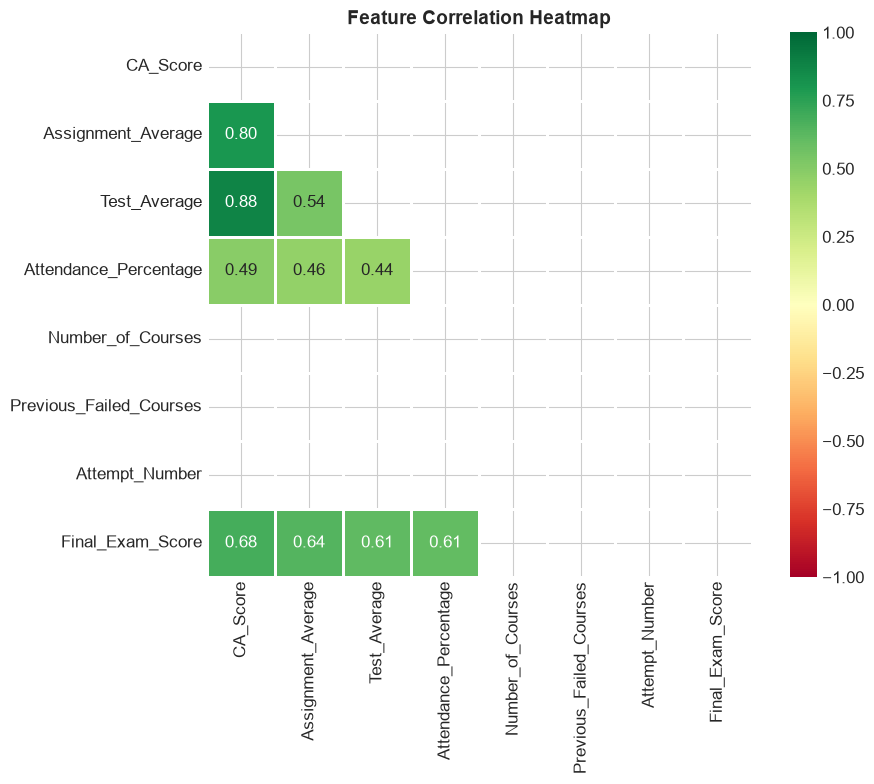

In [7]:
# Correlation heatmap of numeric features
numeric_cols = ['CA_Score', 'Assignment_Average', 'Test_Average', 
                'Attendance_Percentage', 'Number_of_Courses',
                'Previous_Failed_Courses', 'Attempt_Number', 'Final_Exam_Score']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=1, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data_science/data/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. CA Score vs Attendance — Scatter Plot

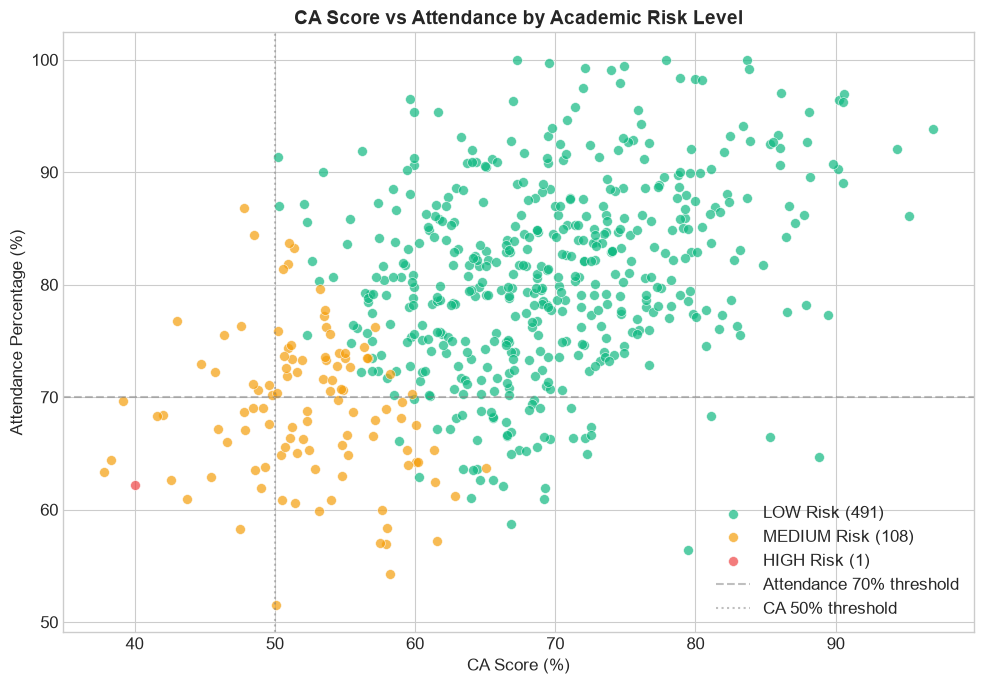

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

for risk in ['LOW', 'MEDIUM', 'HIGH']:
    subset = df[df['Academic_Risk'] == risk]
    ax.scatter(subset['CA_Score'], subset['Attendance_Percentage'],
              c=risk_colors[risk], label=f'{risk} Risk ({len(subset)})',
              alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

# Add threshold lines
ax.axhline(y=70, color='gray', linestyle='--', alpha=0.5, label='Attendance 70% threshold')
ax.axvline(x=50, color='gray', linestyle=':', alpha=0.5, label='CA 50% threshold')

ax.set_xlabel('CA Score (%)', fontsize=12)
ax.set_ylabel('Attendance Percentage (%)', fontsize=12)
ax.set_title('CA Score vs Attendance by Academic Risk Level', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data_science/data/04_ca_vs_attendance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Performance by Course

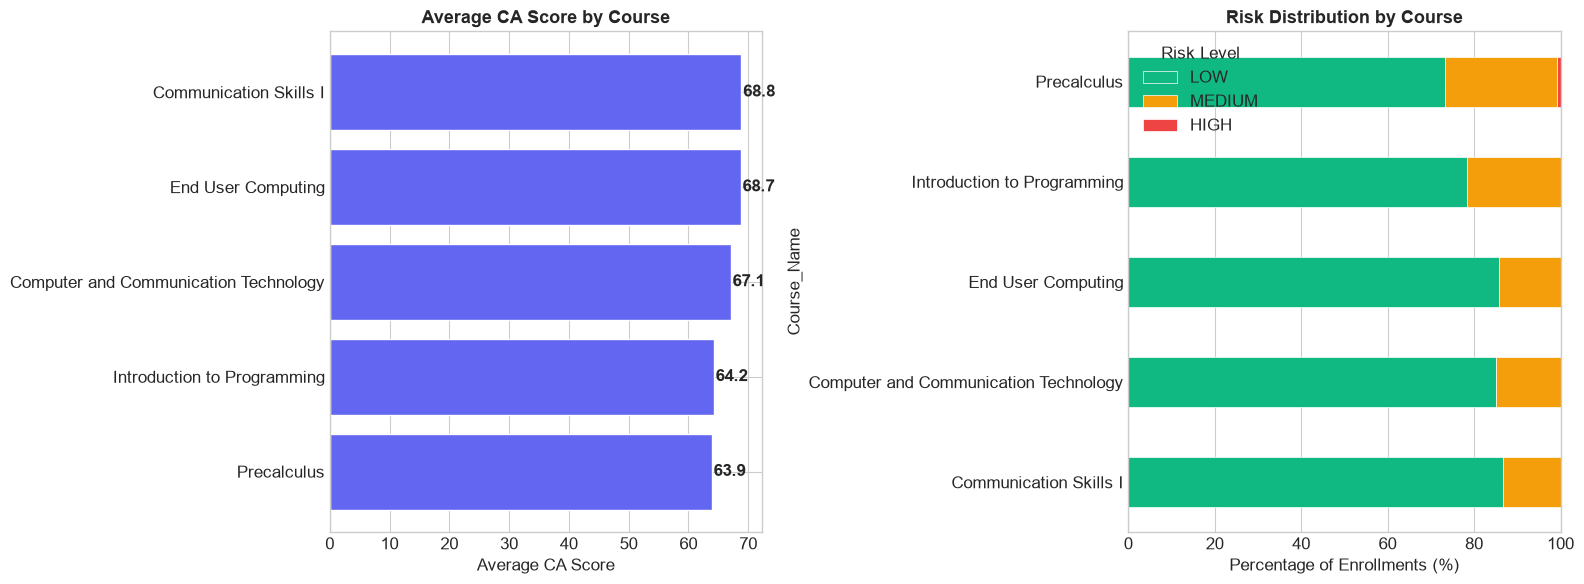

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average CA Score by course
course_ca = df.groupby('Course_Name')['CA_Score'].mean().sort_values()
axes[0].barh(course_ca.index, course_ca.values, color='#6366F1', edgecolor='white')
axes[0].set_xlabel('Average CA Score')
axes[0].set_title('Average CA Score by Course', fontsize=13, fontweight='bold')
for i, val in enumerate(course_ca.values):
    axes[0].text(val + 0.3, i, f'{val:.1f}', va='center', fontweight='bold')

# Risk distribution by course
risk_by_course = pd.crosstab(df['Course_Name'], df['Academic_Risk'], normalize='index') * 100
risk_by_course[['LOW', 'MEDIUM', 'HIGH']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#10B981', '#F59E0B', '#EF4444'],
    edgecolor='white', linewidth=0.5
)
axes[1].set_xlabel('Percentage of Enrollments (%)')
axes[1].set_title('Risk Distribution by Course', fontsize=13, fontweight='bold')
axes[1].legend(title='Risk Level')

plt.tight_layout()
plt.savefig('../data_science/data/05_course_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Box Plots — Risk Level vs Key Metrics

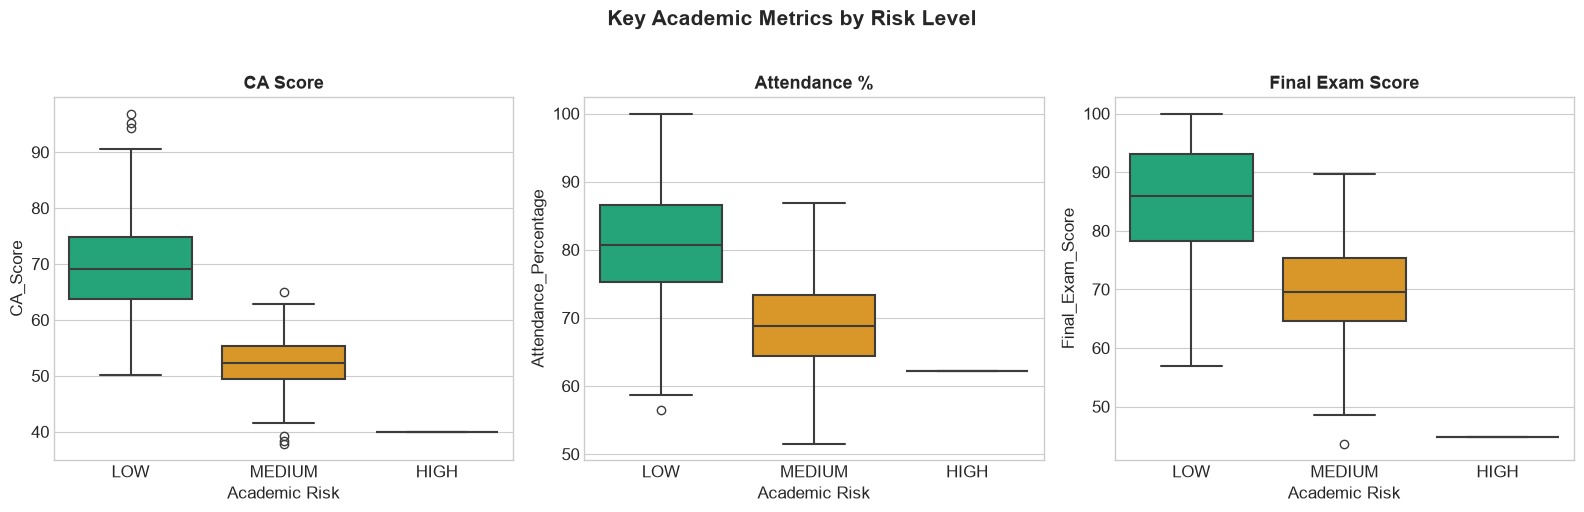

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['CA_Score', 'Attendance_Percentage', 'Final_Exam_Score']
titles = ['CA Score', 'Attendance %', 'Final Exam Score']

for ax, metric, title in zip(axes, metrics, titles):
    order = ['LOW', 'MEDIUM', 'HIGH']
    present = [r for r in order if r in df['Academic_Risk'].unique()]
    palette = {r: risk_colors[r] for r in present}
    sns.boxplot(data=df, x='Academic_Risk', y=metric, order=present,
               palette=palette, ax=ax, linewidth=1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Academic Risk')

plt.suptitle('Key Academic Metrics by Risk Level', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data_science/data/06_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Student-Level Analysis

In [11]:
# Aggregate to student level
student_df = df.groupby('Student_ID').agg(
    Gender=('Gender', 'first'),
    Avg_CA=('CA_Score', 'mean'),
    Avg_Attendance=('Attendance_Percentage', 'mean'),
    Avg_Assignment=('Assignment_Average', 'mean'),
    Avg_Test=('Test_Average', 'mean'),
    Avg_Final_Exam=('Final_Exam_Score', 'mean'),
    Courses_Failed=('Final_Result', lambda x: (x == 'FAIL').sum()),
    High_Risk_Courses=('Academic_Risk', lambda x: (x == 'HIGH').sum()),
    Medium_Risk_Courses=('Academic_Risk', lambda x: (x == 'MEDIUM').sum()),
).reset_index()

# Derive overall student risk
def overall_risk(row):
    if row['High_Risk_Courses'] > 0 or row['Courses_Failed'] >= 2:
        return 'HIGH'
    elif row['Medium_Risk_Courses'] >= 2 or row['Courses_Failed'] >= 1:
        return 'MEDIUM'
    else:
        return 'LOW'

student_df['Overall_Risk'] = student_df.apply(overall_risk, axis=1)

print(f'Total students: {len(student_df)}')
print(f'\nOverall student risk distribution:')
print(student_df['Overall_Risk'].value_counts())
print(f'\nStudents who failed at least 1 course: {(student_df["Courses_Failed"] > 0).sum()}')
student_df.head(10)

Total students: 120

Overall student risk distribution:
Overall_Risk
LOW       92
MEDIUM    26
HIGH       2
Name: count, dtype: int64

Students who failed at least 1 course: 3


,Student_ID,Gender,Avg_CA,Avg_Attendance,Avg_Assignment,Avg_Test,Avg_Final_Exam,Courses_Failed,High_Risk_Courses,Medium_Risk_Courses,Overall_Risk
0,BSDS001,Male,56.086,72.342,58.666,51.654,66.724,0,0,2,MEDIUM
1,BSDS002,Female,64.206,73.202,62.516,62.410,76.870,0,0,1,LOW
2,BSDS003,Male,61.268,77.970,70.458,54.182,72.330,0,0,0,LOW
3,BSDS004,Male,73.608,84.242,72.078,77.010,96.650,0,0,0,LOW
4,BSDS005,Male,70.546,81.310,69.800,69.724,85.056,0,0,0,LOW
5,BSDS006,Female,52.846,66.450,51.368,53.292,68.886,0,0,4,MEDIUM
6,BSDS007,Male,69.028,82.762,69.540,69.242,90.628,0,0,0,LOW
7,BSDS008,Male,64.124,72.580,64.328,64.716,77.524,0,0,1,LOW
8,BSDS009,Male,61.808,74.254,60.402,61.434,80.848,0,0,1,LOW
9,BSDS010,Female,66.468,84.878,71.410,64.214,93.094,0,0,0,LOW


## 10. Key Findings Summary

### Observations:
1. **Severe class imbalance**: LOW risk dominates (491/600 = 81.8%). MEDIUM risk is 18% (108/600). HIGH risk has only 1 sample.
2. **CA Score is the strongest predictor**: MEDIUM risk students have CA < 65, LOW risk students have CA > 50.
3. **Attendance correlates with risk**: MEDIUM risk students have lower attendance (mean ~69%) vs LOW risk (mean ~81%).
4. **Very few failures**: Only 5 out of 600 enrollments resulted in FAIL.
5. **All students are Year 1, Semester 1**: No Previous_Semester_GPA available.
6. **Model training will use `Academic_Risk` as target** with SMOTE or class weighting to handle imbalance.

### Implications for Modeling:
- Need to handle severe class imbalance (especially HIGH class with only 1 sample)
- May need to merge HIGH into MEDIUM to create a binary or 2-class problem
- CA_Score, Attendance_Percentage, and Test_Average are the most important features
- Course-level prediction is the primary granularity